# Member 2 — XGBoost
**Algorithm:** XGBoost — Extreme Gradient Boosting (Supervised)  
**Dataset:** NSL-KDD (`nsl_kdd_dataset.csv`) — 41 pre-scaled features  
**Training data:** SMOTE-balanced (from shared preprocessing)

### Hyperparameter Tuning Strategy
- **Phase 1:** `RandomizedSearchCV` — wide exploration (50 iterations, 5-fold CV)
- **Phase 2:** `GridSearchCV` — fine-grained search around best params (5-fold CV)
- SHAP values for model explainability
- Learning curve to diagnose overfitting

## 1. Import Libraries

In [1]:
import pickle, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.model_selection import (
    StratifiedKFold, RandomizedSearchCV, GridSearchCV, cross_val_score
)
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score, accuracy_score,
    roc_auc_score, roc_curve
)
from scipy.stats import uniform, randint

try:
    import shap
    SHAP_OK = True
    print('SHAP available.')
except ImportError:
    SHAP_OK = False
    print('SHAP not found. Run: pip install shap')

print('Libraries loaded.')

SHAP available.
Libraries loaded.


## 2. Load Preprocessed Data

In [2]:
with open('../data/processed/preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train      = data['X_train']
X_test       = data['X_test']
y_train      = data['y_train']
y_test       = data['y_test']
feature_cols = data['feature_cols']

# After SMOTE, classes are balanced — no need for scale_pos_weight
n_neg = int(np.sum(y_train == 0))
n_pos = int(np.sum(y_train == 1))
print(f'X_train (SMOTE) : {X_train.shape} | normal={n_neg}, attack={n_pos}')
print(f'X_test  (real)  : {X_test.shape}')
print(f'scale_pos_weight: {n_neg/n_pos:.4f} (≈1.0 after SMOTE)')

X_train (SMOTE) : (5670, 41) | normal=2835, attack=2835
X_test  (real)  : (886, 41)
scale_pos_weight: 1.0000 (≈1.0 after SMOTE)


## 3. Phase 1 — RandomizedSearchCV (Wide)

In [5]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_dist = {
    'n_estimators'        : randint(100, 800),
    'max_depth'           : randint(3, 12),
    'learning_rate'       : uniform(0.01, 0.3),
    'subsample'           : uniform(0.6, 0.4),
    'colsample_bytree'    : uniform(0.5, 0.5),
    'colsample_bylevel'   : uniform(0.5, 0.5),
    'min_child_weight'    : randint(1, 10),
    'gamma'               : uniform(0, 0.5),
    'reg_alpha'           : uniform(0, 1.0),
    'reg_lambda'          : uniform(0.5, 2.0),
}

xgb_rand = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=50,
    cv=cv5,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
xgb_rand.fit(X_train, y_train)
bp = xgb_rand.best_params_ 
print(f'\nBest params (random): {xgb_rand.best_params_}')
print(f'Best CV F1 (random) : {xgb_rand.best_score_:.4f}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best params (random): {'colsample_bylevel': np.float64(0.8408068344863948), 'colsample_bytree': np.float64(0.67031228473212), 'gamma': np.float64(0.13034726411795156), 'learning_rate': np.float64(0.15881123628802185), 'max_depth': 7, 'min_child_weight': 2, 'n_estimators': 592, 'reg_alpha': np.float64(0.9366481518557073), 'reg_lambda': np.float64(0.5783726533512925), 'subsample': np.float64(0.7671784126862315)}
Best CV F1 (random) : 0.8772


## 4. Phase 2 — GridSearchCV (Fine)

In [7]:
def rnd(v, step, n=1, low=0.01):  # reduce neighborhood
    return sorted(set([round(max(low, v + i*step), 4) for i in range(-n, n+1)]))

param_grid = {
    'n_estimators'  : [bp['n_estimators']-50, bp['n_estimators'], bp['n_estimators']+50],
    'max_depth'     : [bp['max_depth']-1, bp['max_depth']],
    'learning_rate' : rnd(bp['learning_rate'], 0.02, n=1),
    'reg_alpha'     : rnd(bp['reg_alpha'], 0.1, n=1),
}

xgb_grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=cv5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
xgb_grid.fit(X_train, y_train)

best_params = xgb_grid.best_params_
print(f'\nBest params (grid) : {best_params}')
print(f'Best CV F1 (grid)  : {xgb_grid.best_score_:.4f}')

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best params (grid) : {'learning_rate': np.float64(0.1388), 'max_depth': 7, 'n_estimators': 542, 'reg_alpha': np.float64(1.0366)}
Best CV F1 (grid)  : 0.8882


## 5. Train Final XGBoost with Best Params

In [8]:
xgb_final = XGBClassifier(
    **best_params,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_final.fit(X_train, y_train,
              eval_set=[(X_test, y_test)], verbose=False)
print('Final XGBoost trained.')

Final XGBoost trained.


## 6. 5-Fold Cross-Validation on Training Set

=== 5-Fold Cross-Validation ===
F1       : 0.8882  ± 0.0060
Accuracy : 0.8892 ± 0.0059
ROC-AUC  : 0.9475 ± 0.0033


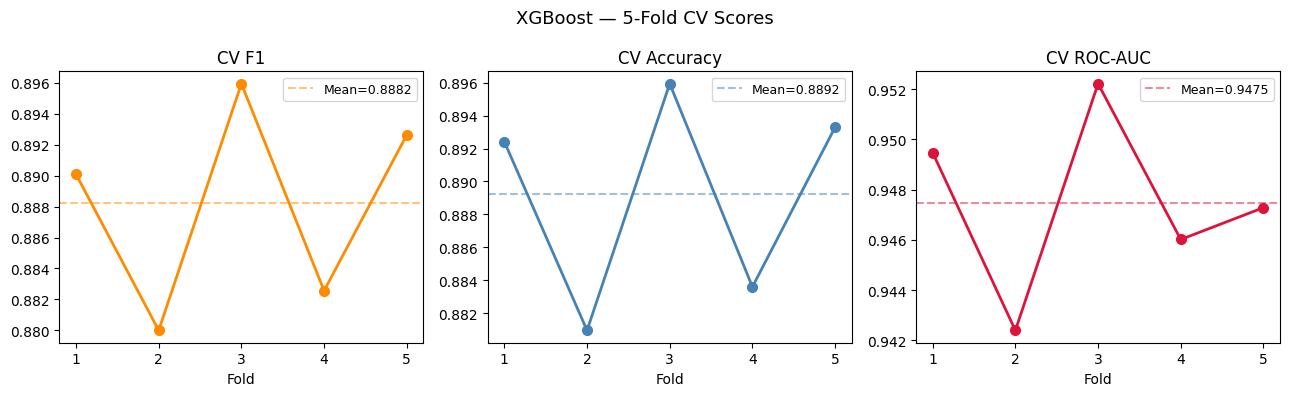

In [9]:
cv_f1  = cross_val_score(xgb_final, X_train, y_train, cv=cv5, scoring='f1',       n_jobs=-1)
cv_acc = cross_val_score(xgb_final, X_train, y_train, cv=cv5, scoring='accuracy', n_jobs=-1)
cv_auc = cross_val_score(xgb_final, X_train, y_train, cv=cv5, scoring='roc_auc',  n_jobs=-1)

print('=== 5-Fold Cross-Validation ===')
print(f'F1       : {cv_f1.mean():.4f}  ± {cv_f1.std():.4f}')
print(f'Accuracy : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
print(f'ROC-AUC  : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, scores, name, color in zip(
    axes, [cv_f1, cv_acc, cv_auc],
    ['F1','Accuracy','ROC-AUC'], ['darkorange','steelblue','crimson']
):
    ax.plot(range(1,6), scores, 'o-', color=color, lw=2, markersize=7)
    ax.axhline(scores.mean(), linestyle='--', color=color, alpha=0.5,
               label=f'Mean={scores.mean():.4f}')
    ax.set_title(f'CV {name}')
    ax.set_xlabel('Fold')
    ax.legend(fontsize=9)
    ax.set_xticks(range(1,6))
plt.suptitle('XGBoost — 5-Fold CV Scores', fontsize=13)
plt.tight_layout()
plt.savefig('cv_scores_xgb.png', dpi=150)
plt.show()

## 7. Test Set Evaluation

In [10]:
y_pred      = xgb_final.predict(X_test)
y_pred_prob = xgb_final.predict_proba(X_test)[:, 1]

print('=== Test Set Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Normal','Attack']))

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
roc_auc   = roc_auc_score(y_test, y_pred_prob)

print(f'Accuracy  : {accuracy:.4f}')
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1 Score  : {f1:.4f}')
print(f'ROC-AUC   : {roc_auc:.4f}')

=== Test Set Classification Report ===
              precision    recall  f1-score   support

      Normal       0.30      0.12      0.17       177
      Attack       0.81      0.93      0.86       709

    accuracy                           0.77       886
   macro avg       0.55      0.52      0.52       886
weighted avg       0.71      0.77      0.73       886

Accuracy  : 0.7675
Precision : 0.8086
Recall    : 0.9295
F1 Score  : 0.8648
ROC-AUC   : 0.4810


## 8. Confusion Matrix, ROC Curve & Learning Curve

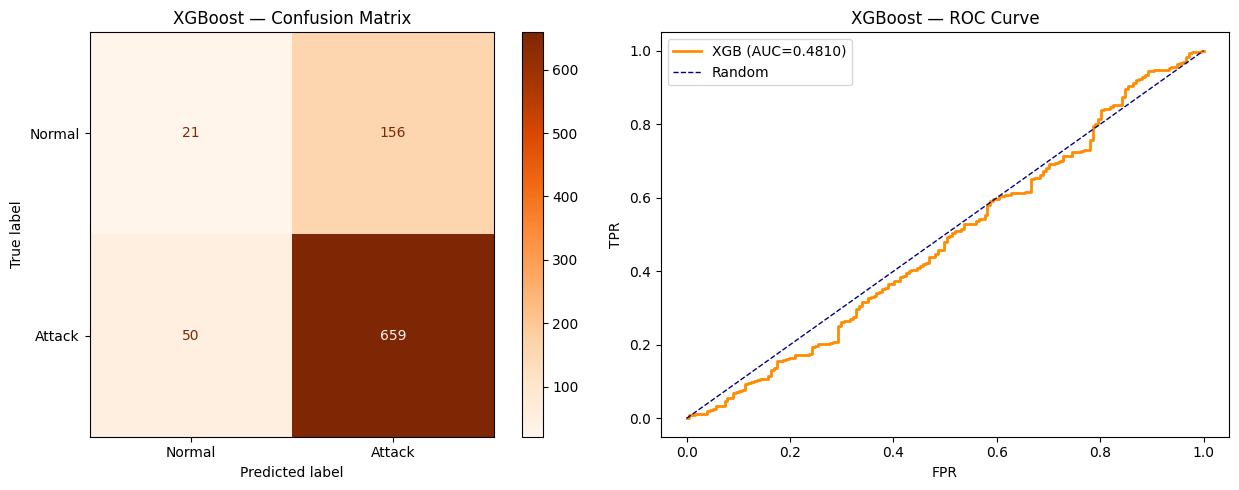

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Normal','Attack']).plot(
    cmap='Oranges', ax=axes[0])
axes[0].set_title('XGBoost — Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'XGB (AUC={roc_auc:.4f})')
axes[1].plot([0,1],[0,1],'--', color='navy', lw=1, label='Random')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].set_title('XGBoost — ROC Curve')
axes[1].legend()
plt.tight_layout()
plt.savefig('cm_roc_xgb.png', dpi=150)
plt.show()

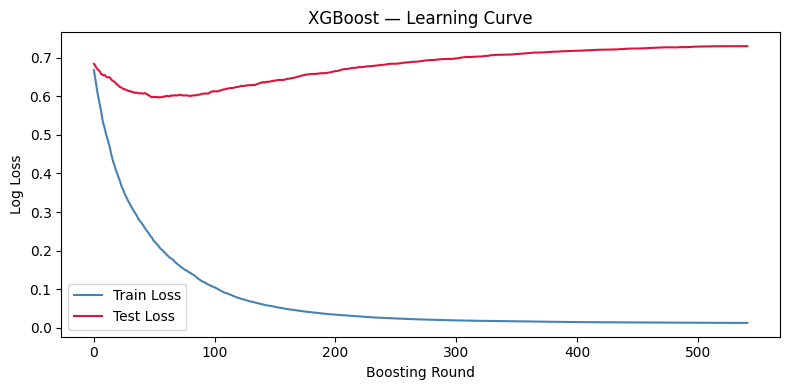

In [12]:
# Learning curve from eval log
xgb_log = XGBClassifier(**best_params, eval_metric='logloss',
                         random_state=42, n_jobs=-1)
xgb_log.fit(X_train, y_train,
            eval_set=[(X_train, y_train),(X_test, y_test)],
            verbose=False)
log = xgb_log.evals_result()
epochs = len(log['validation_0']['logloss'])

plt.figure(figsize=(8, 4))
plt.plot(range(epochs), log['validation_0']['logloss'], label='Train Loss', color='steelblue')
plt.plot(range(epochs), log['validation_1']['logloss'], label='Test Loss',  color='crimson')
plt.xlabel('Boosting Round')
plt.ylabel('Log Loss')
plt.title('XGBoost — Learning Curve')
plt.legend()
plt.tight_layout()
plt.savefig('learning_curve_xgb.png', dpi=150)
plt.show()

## 9. Feature Importance & SHAP

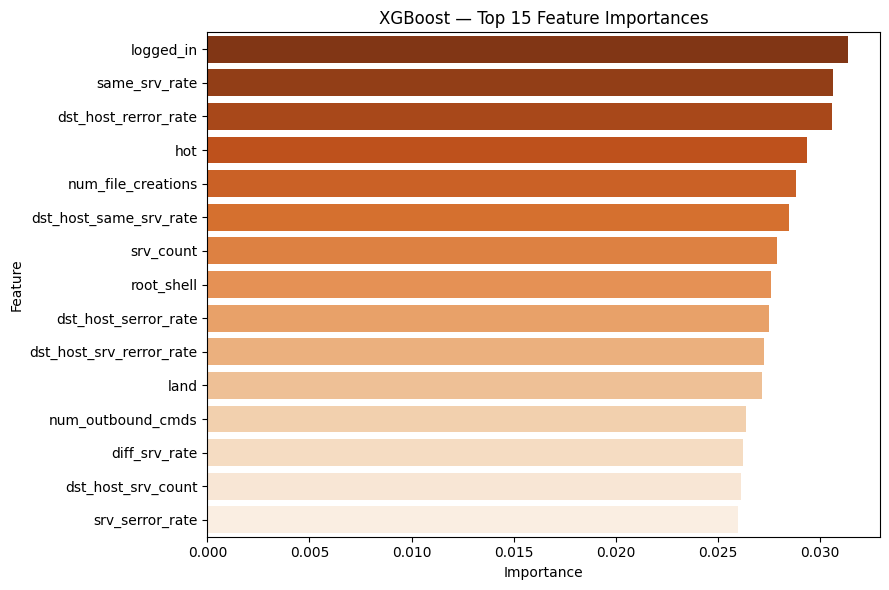

In [13]:
feat_df = pd.DataFrame({'Feature': feature_cols,
                        'Importance': xgb_final.feature_importances_})\
            .sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(data=feat_df.head(15), x='Importance', y='Feature', palette='Oranges_r')
plt.title('XGBoost — Top 15 Feature Importances')
plt.tight_layout()
plt.savefig('feature_importance_xgb.png', dpi=150)
plt.show()

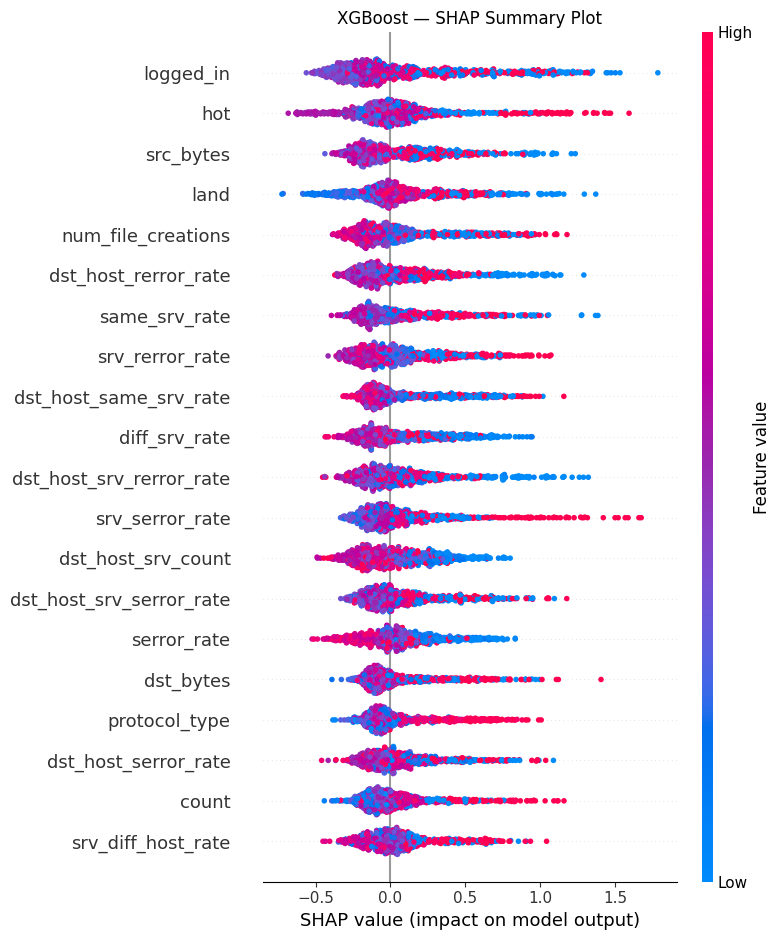

In [14]:
if SHAP_OK:
    n_shap   = min(1000, len(X_test))
    idx_shap = np.random.RandomState(42).choice(len(X_test), n_shap, replace=False)
    X_shap   = X_test[idx_shap]
    explainer   = shap.TreeExplainer(xgb_final)
    shap_values = explainer.shap_values(X_shap)
    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_values, X_shap, feature_names=feature_cols, show=False)
    plt.title('XGBoost — SHAP Summary Plot')
    plt.tight_layout()
    plt.savefig('shap_summary_xgb.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('pip install shap to generate SHAP plots.')

## 10. Save Results

In [15]:
os.makedirs('../comparison', exist_ok=True)
results = pd.DataFrame([{
    'Algorithm':'XGBoost','Type':'Supervised',
    'Accuracy':round(accuracy,4),'Precision':round(precision,4),
    'Recall':round(recall,4),'F1 Score':round(f1,4),'ROC-AUC':round(roc_auc,4),
    'CV F1 Mean':round(cv_f1.mean(),4),'CV F1 Std':round(cv_f1.std(),4)
}])
print(results.to_string(index=False))
results.to_csv('../comparison/results_xgboost.csv', index=False)
print('\nSaved: ../comparison/results_xgboost.csv')

Algorithm       Type  Accuracy  Precision  Recall  F1 Score  ROC-AUC  CV F1 Mean  CV F1 Std
  XGBoost Supervised    0.7675     0.8086  0.9295    0.8648    0.481      0.8882      0.006

Saved: ../comparison/results_xgboost.csv
